In [ ]:
# Customer Data Analysis For Business Insights

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [3]:
df=pd.read_csv("D:/CAREER247/python/mini project/Dataset/Customer_Master_Data.csv")
df.shape

(1000, 9)

In [4]:
df.head()

,CustomerID,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,22-02-2021
1,CUST10001,Divit Kohli,mkalita@sarin.com,Female,48,Kolkata,Married,0,06-12-2023
2,CUST10002,Kiara Behl,apteanay@hotmail.com,Male,75,Kolkata,Widowed,2,23-08-2023
3,CUST10003,Vaibhav Sankar,bseshadri@choudhry.info,Male,62,Pune,Divorced,2,17-11-2022
4,CUST10004,Shray D’Alia,bdhillon@toor-mall.com,Male,55,Delhi,Divorced,0,04-12-2022


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1000 non-null   object
 1   Name           1000 non-null   object
 2   Email          1000 non-null   object
 3   Gender         1000 non-null   object
 4   Age            1000 non-null   int64 
 5   City           1000 non-null   object
 6   MaritalStatus  1000 non-null   object
 7   NumChildren    1000 non-null   int64 
 8   JoinDate       1000 non-null   object
dtypes: int64(2), object(7)
memory usage: 70.4+ KB


In [6]:
pd.isnull(df).sum()

CustomerID       0
Name             0
Email            0
Gender           0
Age              0
City             0
MaritalStatus    0
NumChildren      0
JoinDate         0
dtype: int64

In [7]:
df.columns

Index(['CustomerID', 'Name', 'Email', 'Gender', 'Age', 'City', 'MaritalStatus',
       'NumChildren', 'JoinDate'],
      dtype='object')

In [8]:
df[['Age','NumChildren']].describe()

,Age,NumChildren
count,1000.000000,1000.000000
mean,46.471000,1.311000
std,16.582525,1.190671
min,18.000000,0.000000
25%,32.000000,0.000000
50%,46.000000,1.000000
75%,60.000000,2.000000
max,75.000000,4.000000


In [9]:
df['CustomerID'].duplicated().sum()

np.int64(0)

In [10]:
df['JoinDate'] = pd.to_datetime(df['JoinDate'])

C:\Users\Acer\AppData\Local\Temp\ipykernel_12280\719030103.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['JoinDate'] = pd.to_datetime(df['JoinDate'])


In [11]:
df2=pd.read_csv("D:/CAREER247/python/mini project/Dataset/Customer_Transactions.csv")
df2.shape

(23050, 3)

In [12]:
df2.head()

,CustomerID,TransactionDate,TransactionAmount
0,CUST10771,7/31/23,2383.07
1,CUST10100,3/10/24,497.54
2,CUST10031,2/17/25,536.78
3,CUST10987,7/17/23,314.89
4,CUST10831,12/15/24,2543.19


In [13]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23050 entries, 0 to 23049
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         23050 non-null  object 
 1   TransactionDate    23050 non-null  object 
 2   TransactionAmount  23050 non-null  float64
dtypes: float64(1), object(2)
memory usage: 540.4+ KB


In [14]:
df2['TrasactionAmount']=df2['TransactionAmount'].astype('int')

In [15]:
df2.describe()

,TransactionAmount,TrasactionAmount
count,23050.000000,23050.000000
mean,1000.138814,999.641909
std,703.358978,703.364014
min,3.870000,3.000000
25%,482.107500,482.000000
50%,844.755000,844.000000
75%,1346.795000,1346.000000
max,6890.190000,6890.000000


In [16]:
df2.columns

Index(['CustomerID', 'TransactionDate', 'TransactionAmount',
       'TrasactionAmount'],
      dtype='object')

In [17]:
df2['TransactionDate'] = pd.to_datetime(df2['TransactionDate'])

C:\Users\Acer\AppData\Local\Temp\ipykernel_12280\165618037.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df2['TransactionDate'] = pd.to_datetime(df2['TransactionDate'])


In [18]:
df = df.dropna(subset=['CustomerID', 'JoinDate'])
df2 = df2.dropna(subset=['CustomerID', 'TransactionDate', 'TransactionAmount'])

In [19]:
invalid_ids = set(df2['CustomerID']) - set(df['CustomerID'])
if invalid_ids:
    print(f"\n⚠️ Transactions contain invalid CustomerIDs: {invalid_ids}")
else:
    print("\n✅ All Transaction CustomerIDs match the master Customers dataset.")


✅ All Transaction CustomerIDs match the master Customers dataset.


In [20]:
Fulldata_set = pd.merge(
    df2,
    df,
    on='CustomerID')


In [21]:
Fulldata_set

,CustomerID,TransactionDate,TransactionAmount,TrasactionAmount,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10771,2023-07-31,2383.07,2383,Lakshay Dhillon,dharmajantara@gmail.com,Female,27,Ahmedabad,Widowed,3,2023-05-31
1,CUST10100,2024-03-10,497.54,497,Aniruddh Borah,jivikabhavsar@gmail.com,Female,53,Lucknow,Divorced,4,2022-01-08
2,CUST10031,2025-02-17,536.78,536,Ritvik Ahuja,jhaverifarhan@chandra.org,Male,40,Ahmedabad,Single,0,2023-12-03
3,CUST10987,2023-07-17,314.89,314,Jayan Wagle,ojas82@gmail.com,Not Disclosed,75,Bangalore,Widowed,4,2022-03-18
4,CUST10831,2024-12-15,2543.19,2543,Ishita Agarwal,vbalay@yahoo.com,Not Disclosed,27,Jaipur,Divorced,4,2021-06-30
...,...,...,...,...,...,...,...,...,...,...,...,...
23045,CUST10710,2024-03-11,931.09,931,Divit Toor,saksham79@ram.biz,Not Disclosed,73,Mumbai,Widowed,1,2024-02-18
23046,CUST10209,2024-06-19,2659.35,2659,Jivin Cheema,darivana@hotmail.com,Male,56,Pune,Married,1,2024-05-09
23047,CUST10570,2024-06-27,266.97,266,Advika Dyal,granganathan@sathe-dhar.org,Not Disclosed,26,Pune,Single,1,2021-03-29
23048,CUST10075,2023-12-26,1671.73,1671,Amira Lall,vanyabiswas@kannan.biz,Female,29,Jaipur,Married,1,2023-02-25


In [22]:
print("Merged dataset shape:", Fulldata_set.shape)
print("\nMerged Data Preview:")
print(Fulldata_set.head())

Merged dataset shape: (23050, 12)

Merged Data Preview:
  CustomerID TransactionDate  TransactionAmount  TrasactionAmount  \
0  CUST10771      2023-07-31            2383.07              2383   
1  CUST10100      2024-03-10             497.54               497   
2  CUST10031      2025-02-17             536.78               536   
3  CUST10987      2023-07-17             314.89               314   
4  CUST10831      2024-12-15            2543.19              2543   

              Name                      Email         Gender  Age       City  \
0  Lakshay Dhillon    dharmajantara@gmail.com         Female   27  Ahmedabad   
1   Aniruddh Borah    jivikabhavsar@gmail.com         Female   53    Lucknow   
2     Ritvik Ahuja  jhaverifarhan@chandra.org           Male   40  Ahmedabad   
3      Jayan Wagle           ojas82@gmail.com  Not Disclosed   75  Bangalore   
4   Ishita Agarwal           vbalay@yahoo.com  Not Disclosed   27     Jaipur   

  MaritalStatus  NumChildren   JoinDate  
0     

In [23]:
print("\nMissing values after merge:")
print(Fulldata_set.isnull().sum())


Missing values after merge:
CustomerID           0
TransactionDate      0
TransactionAmount    0
TrasactionAmount     0
Name                 0
Email                0
Gender               0
Age                  0
City                 0
MaritalStatus        0
NumChildren          0
JoinDate             0
dtype: int64


In [113]:
pd.Timedelta(days=1)

Timedelta('1 days 00:00:00')

In [24]:
Fulldata_set['TransactionDate'] = pd.to_datetime(Fulldata_set['TransactionDate'])

In [25]:
reference_date = Fulldata_set['TransactionDate'].max() + pd.Timedelta(days=1)

print("Reference Date:", reference_date)

Reference Date: 2025-07-30 00:00:00


In [ ]:
#Step 2: Calculate Individual RFM Metrics
#Group by CustomerID to summarize their transactions

In [26]:
df_rfm = Fulldata_set.groupby('CustomerID').agg({
    'TransactionDate': lambda x: (reference_date - x.max()).days,  # Recency
    'CustomerID': 'count',                                         # Frequency
    'TransactionAmount': 'sum'                                     # Monetary
})

In [27]:
df_rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [28]:
print(df_rfm.head(10))

            Recency  Frequency  Monetary
CustomerID                              
CUST10000        13         23  21265.49
CUST10001        35         30  28654.31
CUST10002        18         24  23884.03
CUST10003        81         25  24206.03
CUST10004         8         19  25565.30
CUST10005        24         29  29459.82
CUST10006        11         28  27922.36
CUST10007        86         15  14957.06
CUST10008         3         19  19479.25
CUST10009         7         25  22832.83


In [29]:
df_rfm['R_Score'] = pd.qcut(df_rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])


In [31]:
df_rfm['F_Score'] = pd.qcut(df_rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])


In [30]:
df_rfm['M_Score'] = pd.qcut(df_rfm['Monetary'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])

In [32]:
df_rfm['RFM_Segment'] = df_rfm['R_Score'].astype(str) + df_rfm['F_Score'].astype(str) + df_rfm['M_Score'].astype(str)

In [33]:
print(df_rfm.head())

            Recency  Frequency  Monetary R_Score M_Score F_Score RFM_Segment
CustomerID                                                                  
CUST10000        13         23  21265.49       4       2       3         432
CUST10001        35         30  28654.31       3       5       5         355
CUST10002        18         24  23884.03       4       3       3         433
CUST10003        81         25  24206.03       1       3       4         143
CUST10004         8         19  25565.30       5       4       1         514


In [34]:
df_rfm['RFM_Segment'] = (
    df_rfm['R_Score'].astype(str) +
    df_rfm['F_Score'].astype(str) +
    df_rfm['M_Score'].astype(str)
)

In [35]:
# Optional: calculate an overall average RFM Score
df_rfm['RFM_Score'] = (
    df_rfm[['R_Score', 'F_Score', 'M_Score']].astype(int).mean(axis=1)
)

In [36]:
df_rfm = df_rfm.reset_index()

In [37]:
# Display sample
print("\n Combined RFM Segments:")
print(df_rfm[['CustomerID', 'R_Score', 'F_Score', 'M_Score', 'RFM_Segment', 'RFM_Score']].head())


 Combined RFM Segments:
  CustomerID R_Score F_Score M_Score RFM_Segment  RFM_Score
0  CUST10000       4       3       2         432   3.000000
1  CUST10001       3       5       5         355   4.333333
2  CUST10002       4       3       3         433   3.333333
3  CUST10003       1       4       3         143   2.666667
4  CUST10004       5       1       4         514   3.333333


In [38]:
def assign_segment(r, f, m):
    rfm_score = int(str(r) + str(f) + str(m))
    
    if r == 5 and f == 5 and m == 5:
        return 'Champion'
    elif r >= 4 and f >= 4 and m >= 4:
        return 'Loyal Customer'
    elif r >= 4 and f >= 2:
        return 'Potential Loyalist'
    elif r >= 3 and f >= 3:
        return 'Needs Attention'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'At Risk / Lost'
    else:
        return 'Others'

# Apply the segmentation function
df_rfm['Segment'] = df_rfm.apply(
    lambda row: assign_segment(row['R_Score'], row['F_Score'], row['M_Score']), axis=1
)

# Display summary
print("\n✅ RFM Segmentation Completed:")
print(df_rfm[['CustomerID', 'RFM_Segment', 'RFM_Score', 'Segment']].head())


✅ RFM Segmentation Completed:
  CustomerID RFM_Segment  RFM_Score             Segment
0  CUST10000         432   3.000000  Potential Loyalist
1  CUST10001         355   4.333333     Needs Attention
2  CUST10002         433   3.333333  Potential Loyalist
3  CUST10003         143   2.666667              Others
4  CUST10004         514   3.333333              Others


C:\Users\Acer\AppData\Local\Temp\ipykernel_12280\382360272.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Segment', data=df_rfm, order=df_rfm['Segment'].value_counts().index, palette='viridis')


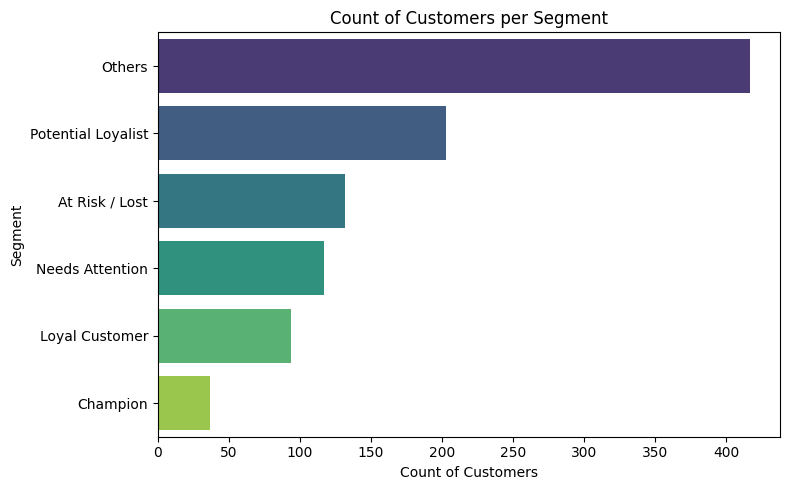

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(y='Segment', data=df_rfm, order=df_rfm['Segment'].value_counts().index, palette='viridis')
plt.title('Count of Customers per Segment')
plt.xlabel('Count of Customers')
plt.ylabel('Segment')
plt.tight_layout()
plt.show()


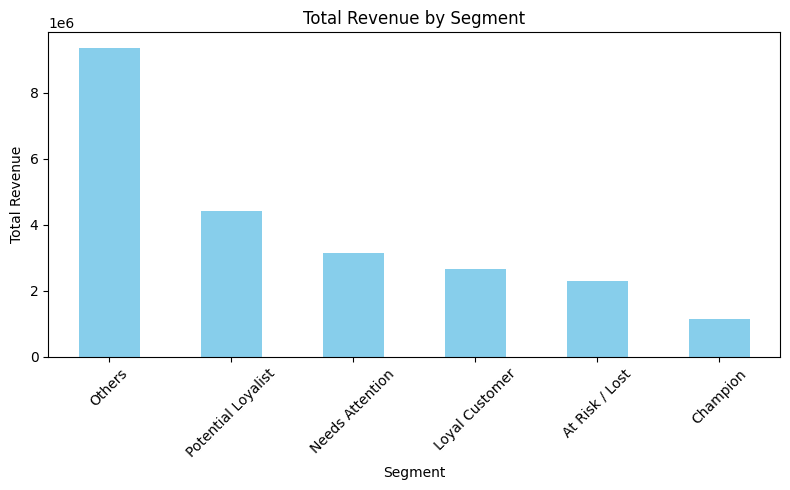

In [42]:
segment_revenue = df_rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
segment_revenue.plot(kind='bar', color='skyblue')
plt.title('Total Revenue by Segment')
plt.ylabel('Total Revenue')
plt.xlabel('Segment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


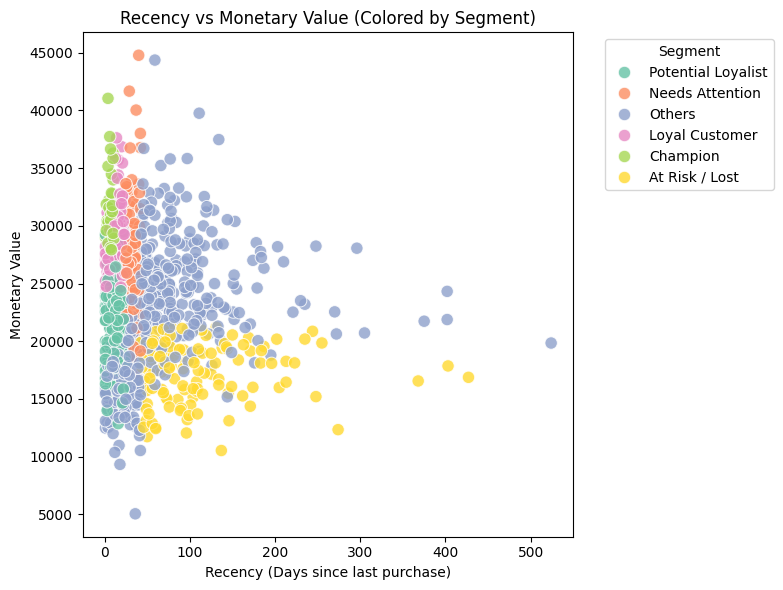

In [43]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_rfm, x='Recency', y='Monetary', hue='Segment', palette='Set2', s=80, alpha=0.8)
plt.title('Recency vs Monetary Value (Colored by Segment)')
plt.xlabel('Recency (Days since last purchase)')
plt.ylabel('Monetary Value')
plt.legend(title='Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


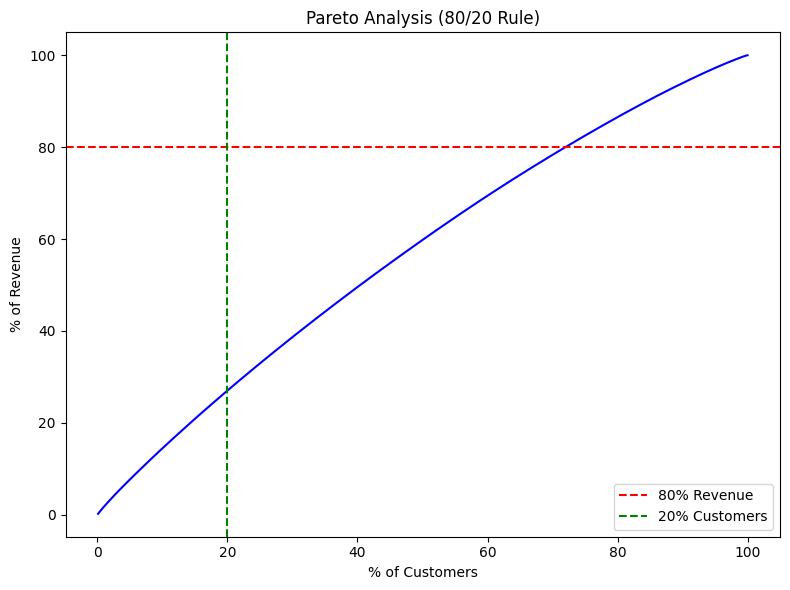

In [43]:
# Sort customers by Monetary descending
pareto_df = df_rfm.sort_values(by='Monetary', ascending=False).reset_index(drop=True)

# Calculate cumulative revenue share
pareto_df['Cumulative_Revenue'] = pareto_df['Monetary'].cumsum()
pareto_df['Cumulative_Percent'] = 100 * pareto_df['Cumulative_Revenue'] / pareto_df['Monetary'].sum()
pareto_df['Customer_Percent'] = 100 * (pareto_df.index + 1) / len(pareto_df)

# Plot
plt.figure(figsize=(8,6))
plt.plot(pareto_df['Customer_Percent'], pareto_df['Cumulative_Percent'], color='blue')
plt.axhline(y=80, color='r', linestyle='--', label='80% Revenue')
plt.axvline(x=20, color='g', linestyle='--', label='20% Customers')
plt.title('Pareto Analysis (80/20 Rule)')
plt.xlabel('% of Customers')
plt.ylabel('% of Revenue')
plt.legend()
plt.tight_layout()
plt.show()
